# RadHarmony — A Hands-On Introduction

This notebook is a practical introduction to RadHarmony. It shows how to load a
medical-imaging dataset, inspect its contents, and pass it to the standard tools
used to train and evaluate models — without writing a custom data loader for
each dataset.

No prior machine-learning experience is assumed. Technical terms are defined the
first time they appear.

### The problem RadHarmony solves

Public chest X-ray and CT datasets are each stored differently: different folder
layouts, different file formats (DICOM, PNG, JPEG, NIfTI), and different label
columns in their metadata files. Reading each one normally requires
dataset-specific code before any modeling can begin.

RadHarmony provides a single, consistent interface across roughly 30 datasets.
The code you learn for one dataset applies to all of them.

**Harmonize:** to convert differently-organized datasets into one common format.
This is the core function the library provides.

### Contents

| § | Topic |
|---|---|
| 1 | Loading a dataset |
| 2 | Inspecting a sample (image and label) |
| 3 | Segmentation masks |
| 4 | Using a dataset with a PyTorch `DataLoader` |
| 5 | The dataset registry |
| 6 | Evaluating a foundation model (concept) |

## Setup

RadHarmony is installed with [`uv`](https://docs.astral.sh/uv/) (see the README).
The imports below assume it is already available in the environment.

The examples use the **Montgomery County chest X-ray set**: 138 images, roughly
half normal and half tuberculosis-positive. Its small size keeps each step fast.

In [1]:
import torch
import matplotlib.pyplot as plt

# The only path you ever need to point at: the folder of images.
MONTGOMERY_DIR = "/mnt/NAS4/datasets/external/Montgomery-CXR/MontgomerySet/CXR_png/"

# A scratch folder for cached / derived files (safe to delete anytime).
CACHE_DIR = "./cache/montgomery"

## 1. Loading a dataset

Each dataset in RadHarmony is a Python class. You provide the location of the
images and specify which outputs you need, then request the data.

In [2]:
from radharmony.dataset import MontgomeryCXRDataset

ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    output_cls=True,  # also return the classification label
    cache_dir=CACHE_DIR,
)

# get_datasets() returns ready-to-use data. With n_splits it reserves a
# validation slice; no patient appears in both splits.
train_ds, val_ds = ds.get_datasets(n_splits=5)

print(f"Training images  : {len(train_ds)}")
print(f"Validation images: {len(val_ds)}")
print(f"Label(s)         : {MontgomeryCXRDataset.LABEL_COLS}")

Training images  : 110
Validation images: 28
Label(s)         : ['tb']


`train_ds` and `val_ds` behave like ordinary Python sequences: they support
`len()` and indexing.

**Validation set:** data held back from training and used to assess whether the
model has learned general patterns rather than memorized the training images.
RadHarmony splits by patient, ensuring that images from the same patient do not
appear in both the training and validation sets — a common source of misleading
results if not controlled.

## 2. Inspecting a sample

Indexing into the dataset returns a single sample as a Python dictionary. Because
`output_cls=True` was set, it contains two entries:

- `"img"` — the X-ray image, represented as a **tensor** (a grid of numbers).
- `"cls"` — the label, also a tensor (here a single value: 1 = TB, 0 = normal).

In [3]:
sample = train_ds[0]

print("Keys in the sample :", list(sample.keys()))
print("Image shape        :", tuple(sample["img"].shape), "  (channels, height, width)")
print("Image value range  : [%.2f, %.2f]" % (sample["img"].min(), sample["img"].max()))
print(
    "Label              :", sample["cls"].tolist(), "  (1 = tuberculosis, 0 = normal)"
)

Keys in the sample : ['img', 'cls']
Image shape        : (1, 224, 224)   (channels, height, width)
Image value range  : [-1.00, 1.00]
Label              : [0.0]   (1 = tuberculosis, 0 = normal)


RadHarmony has applied two standardizing steps automatically:

1. **Resizing** every image to a uniform 224×224, so images can be grouped
   together for processing.
2. **Normalizing** pixel values to a range of approximately −1 to 1, the range
   models typically expect as input.

**Tensor:** a multi-dimensional array of numbers. A grayscale image is a 2-D
grid of brightness values; the leading `1` in the shape is the single color
channel.

The following cell displays several images with their labels.

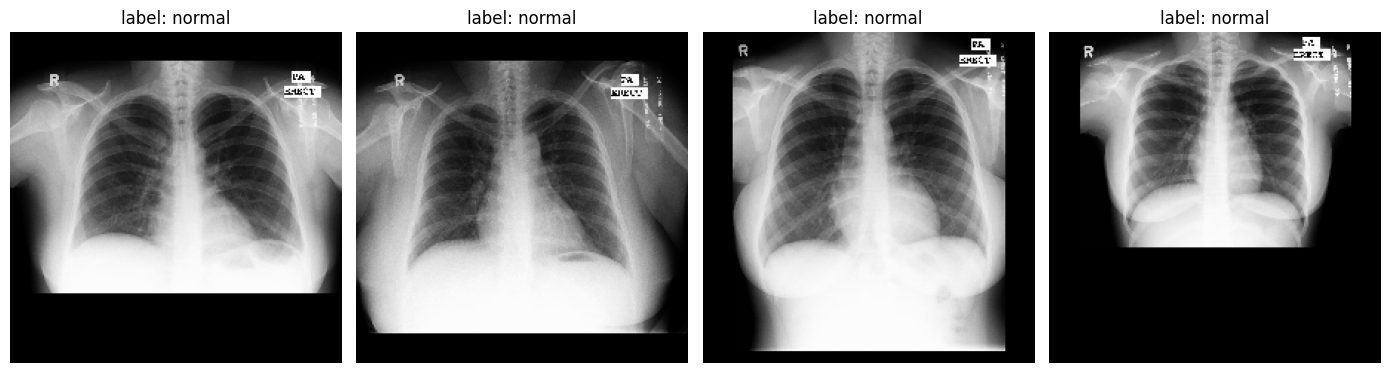

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, i in zip(axes, range(4)):
    s = train_ds[i]
    label = "TB" if s["cls"].item() == 1 else "normal"
    # squeeze() drops the channel dimension so matplotlib can show it as 2-D.
    ax.imshow(s["img"].float().squeeze(), cmap="gray")
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

RadHarmony also provides a built-in viewer, `visualize_samples`, which arranges
this layout automatically and adapts to the outputs that are enabled (labels,
masks, bounding boxes). It yields matplotlib figures one at a time:

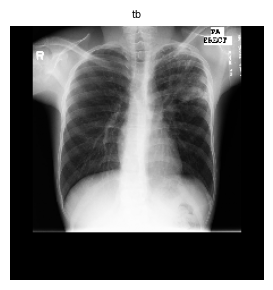

In [5]:
(fig,) = ds.visualize_samples(train_ds, per_label=True, random_state=0)
plt.show()

## 3. Segmentation masks

A label answers whether a finding is present (for example, "is TB present?"). A
**segmentation mask** answers a spatial question, such as which pixels belong to
the lungs. It is a second image, the same size as the X-ray, that marks a region
of interest.

The Montgomery set includes hand-drawn lung outlines, enabled with
`output_mask=True`. RadHarmony fuses the separate left and right outlines into a
single mask file, so it requires an output directory (`mask_output_dir`); this
is done once and reused on subsequent runs.

In [6]:
ds_mask = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    output_cls=True,
    output_mask=True,
    mask_output_dir="./cache/montgomery_masks",
    cache_dir=None,  # no disk cache — fine for a small dataset
)
mask_ds = ds_mask.get_datasets()  # no n_splits → one dataset with everything

s = mask_ds[0]
print("Keys :", list(s.keys()))
print("img  :", tuple(s["img"].shape))
print(
    "mask :",
    tuple(s["mask"].shape),
    " (same size as the image; 1 = lung, 0 = background)",
)

Fusing lung masks: 100%|██████████| 138/138 [00:00<00:00, 49462.82it/s]


Keys : ['img', 'cls', 'mask']
img  : (1, 224, 224)
mask : (1, 224, 224)  (same size as the image; 1 = lung, 0 = background)


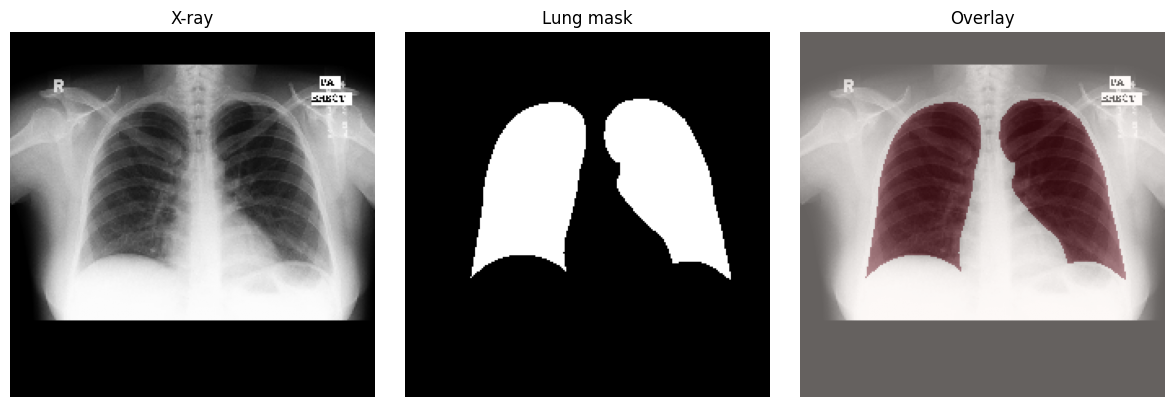

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
img = s["img"].float().squeeze()
mask = s["mask"].float().squeeze()

axes[0].imshow(img, cmap="gray")
axes[0].set_title("X-ray")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Lung mask")
axes[2].imshow(img, cmap="gray")
axes[2].imshow(mask, alpha=0.4, cmap="Reds")
axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Using a dataset with a `DataLoader`

Models are typically trained on **batches** — small groups of samples processed
together — rather than one image at a time. PyTorch's `DataLoader` is the
standard component that groups samples into batches and shuffles them between
passes.

Because a RadHarmony dataset is a standard PyTorch dataset, it can be passed
directly to a `DataLoader` without additional adapter code.

In [8]:
from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# Grab the first batch and see the shapes.
batch = next(iter(loader))
print("Images in one batch :", tuple(batch["img"].shape), " (batch, channels, H, W)")
print("Labels in one batch :", tuple(batch["cls"].shape))

Images in one batch : (8, 1, 224, 224)  (batch, channels, H, W)
Labels in one batch : (8, 1)


The leading `8` is the batch size — eight X-rays grouped together. This `batch`
dictionary is the input a model's training loop expects. Beyond this point the
workflow is standard PyTorch; RadHarmony's role is complete once the data is in
this form.

**Batch:** a group of samples processed together. Larger batches increase
throughput but require more memory.

## 5. The dataset registry

RadHarmony maintains a **registry** that maps a short string name to each
dataset class. This allows a dataset to be selected from a configuration file or
user interface rather than through a hard-coded `import`, and avoids the need to
memorize class names.

In [9]:
from radharmony.registry import list_datasets, resolve_dataset

names = list_datasets()
print(f"{len(names)} datasets available:\n")
for n in names:
    print(" ", n)

54 datasets available:

  brax
  brax_png
  chestxray14
  chestxray14_bbox
  chestxray14_test
  chestxray14_train
  chexpert
  chexpert_plus
  chexpert_train
  chexpert_valid
  ct_rate
  mimic_cxr
  mimic_cxr_jpg
  mimic_cxr_jpg_test
  montgomery_cxr
  openi_cxr
  padchest
  radchestct
  ranzcr_clip
  rexgradient
  rexgradient_test
  rexgradient_train
  rexgradient_valid
  rsna_2022_cervical_spine
  rsna_2022_cervical_spine_bbox
  rsna_2022_cervical_spine_test
  rsna_2022_cervical_spine_train
  rsna_2024_lumbar_spine
  rsna_2024_lumbar_spine_test
  rsna_2024_lumbar_spine_train
  rsna_abdominal_trauma_2023
  rsna_abdominal_trauma_2023_test
  rsna_abdominal_trauma_2023_train
  rsna_bone_age
  rsna_bone_age_train
  rsna_bone_age_val
  rsna_pe_detection
  rsna_pe_detection_test
  rsna_pe_detection_train
  rsna_pneumonia
  rsna_pneumonia_kaggle
  rsna_pneumonia_kaggle_test
  rsna_pneumonia_kaggle_train
  shenzhen_cxr
  siim_acr_ptx
  siim_acr_ptx_test
  siim_acr_ptx_train
  siim_covid19
  s

In [10]:
# Look up a class by its name and use it exactly like a direct import.
DatasetCls = resolve_dataset("montgomery_cxr")

ds = DatasetCls(base_image_dir=MONTGOMERY_DIR, output_cls=True, cache_dir=CACHE_DIR)
train_ds, val_ds = ds.get_datasets(n_splits=5)
print("Loaded", DatasetCls.__name__, "→", len(train_ds), "train images")

Loaded MontgomeryCXRDataset → 110 train images


Switching to a different dataset, such as VinDr-CXR or MIMIC-CXR, requires only a
different name and image directory. The downstream code — the sample dictionary,
the `DataLoader`, and the training loop — remains unchanged. This uniformity
across datasets is the central design goal of RadHarmony.

## 6. Evaluating a foundation model

A **foundation model** is a large model pre-trained on a broad collection of
images. Its learned image representations can be reused for a new task instead
of training a model from scratch. A common and inexpensive evaluation method is
a **linear probe**: the foundation model is kept frozen and used to convert each
image into a compact numeric vector (an *embedding*), and a small classifier is
then fit on top of these vectors.

The example below runs a real linear probe: it uses
[RAD-DINO](https://huggingface.co/microsoft/rad-dino), a chest X-ray foundation
model, to classify tuberculosis on the Montgomery set.

> **Requirements:** this section needs a GPU and the model dependencies. Install
> them with `uv pip install -e ".[model,raddino]"`. The RAD-DINO weights are
> downloaded from Hugging Face on first use.

In [12]:
from radharmony.evaluator.backbones import make_raddino
from radharmony.evaluator import LinearProbeEvaluator

# Set to a specific GPU if the machine is shared, e.g. "cuda:1".
DEVICE = "cuda:7"

# make_raddino returns two things:
#   transform - the preprocessing RAD-DINO expects for each image
#   encoder   - the frozen foundation model that produces embeddings
transform, encoder = make_raddino(device=DEVICE, output_keys={"img", "cls"})

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

The encoder needs images preprocessed its own way, so we build the dataset with
the `transform` returned above instead of RadHarmony's default. Everything else
is the same dataset interface used in Section 1.

In [ ]:
probe_ds = MontgomeryCXRDataset(
    base_image_dir=MONTGOMERY_DIR,
    transform=transform,  # use RAD-DINO's preprocessing
    output_cls=True,
    cache_dir=None,
)

`LinearProbeEvaluator` handles the rest: it extracts an embedding for every
image, then runs 5-fold cross-validation, fitting a simple classifier on each
fold and scoring it on the held-out images.

In [14]:
probe = LinearProbeEvaluator(
    image_encoder=encoder,
    dataset=probe_ds,
    n_folds=5,
    batch_size=32,
    device=DEVICE,
    embedding_cache="./cache/montgomery_raddino_emb",  # embeddings reused on re-runs
)
results = probe.evaluate()

# Average metrics across the folds, per label.
results.groupby("label")[["auroc", "auprc", "f1"]].mean()

,auroc,auprc,f1
label,,,
macro_average,0.958712,0.963892,0.944513
tb,0.958712,0.963892,0.944513


The result is a standardized table of per-label metrics — AUROC, AUPRC, F1, and
several others. Because every foundation model is evaluated through this same
interface, their scores can be compared directly on identical data.

- **AUROC** (area under the ROC curve) summarizes how well the model separates
  positive from negative cases; 1.0 is perfect and 0.5 is chance.

RadHarmony provides several other evaluators with the same interface — k-NN,
SVM, and prototype probes, zero-shot classification, and full fine-tuning — plus
segmentation evaluators. A complete walkthrough is in
[`evaluator_tutorial.ipynb`](evaluator_tutorial.ipynb).

## Summary and next steps

This notebook covered:

1. Loading a medical-imaging dataset.
2. Inspecting a sample — image tensor and label — and visualizing it.
3. Enabling segmentation masks with a single flag.
4. Passing a dataset to a PyTorch `DataLoader` for training.
5. Selecting datasets by name through the registry.
6. Evaluating a foundation model with a linear probe.

The consistent workflow across all datasets is: specify an image directory, set
the required `output_*` flags, and call `get_datasets()` to obtain
PyTorch-ready data.

### Further reading

| Notebook | What it adds |
|---|---|
| [`dataset_api_tour.ipynb`](dataset_api_tour.ipynb) | The full dataset API: harmonizers, preprocessors, k-fold, multi-dataset, options |
| [`custom_dataset_tutorial.ipynb`](custom_dataset_tutorial.ipynb) | Integrating a new dataset into RadHarmony |
| [`evaluator_tutorial.ipynb`](evaluator_tutorial.ipynb) | Running a foundation-model linear probe end to end |

Full documentation: **[f10409.github.io/RadHarmony](https://f10409.github.io/RadHarmony)**